In [1]:
# ==== USGS Streamflow Analysis and Comparison (UPDATED FOR ADDITIONAL DATA) ====
print("=== STREAMFLOW DATA ANALYSIS ===")

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import re
from pathlib import Path
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# Set pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("Libraries loaded successfully")

# ==== Load Enhanced Data from Artifacts ====
print("\n=== LOADING ENHANCED DATA FROM ARTIFACTS ===")

from artifacts_io import load_artifacts

# Load artifacts that include both main and additional data
tables, meta, run_dir = load_artifacts(out_dir="artifacts")
run_id = os.path.basename(run_dir)
print(f"Loaded artifacts from: {run_dir}")

# Get the combined dataset
if "df_combined" in tables:
    restored_df_all = tables["df_combined"].copy()
    print(f"Using df_combined: {len(restored_df_all):,} total sites")
elif "df" in tables:
    restored_df_all = tables["df"].copy()
    print(f"Using df: {len(restored_df_all):,} total sites")
else:
    # Use the largest table
    everything_key = max(tables, key=lambda k: tables[k].shape[0])
    restored_df_all = tables[everything_key].copy()
    print(f"Using {everything_key}: {len(restored_df_all):,} total sites")

# Check for data source information
if 'data_source' in restored_df_all.columns:
    print("Total data source breakdown:")
    print(restored_df_all['data_source'].value_counts())

print("Enhanced dataset loaded successfully")

# ==== Filter to Santa Barbara County Only ====
print("\n=== FILTERING TO SANTA BARBARA COUNTY ===")

# Load Santa Barbara County boundary first
sb_county_shapefile = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\sb_county_shapefile\sb_county_shp.shp"

try:
    sb_county = gpd.read_file(sb_county_shapefile)
    if sb_county.crs is None or sb_county.crs.to_string().upper() not in ("EPSG:4326", "WGS84"):
        sb_county = sb_county.to_crs("EPSG:4326")
    
    sb_county_geom = sb_county.union_all() if hasattr(sb_county, "union_all") else sb_county.unary_union
    SB_COUNTY_GDF = gpd.GeoSeries([sb_county_geom], crs="EPSG:4326")
    print("Loaded Santa Barbara County boundary for filtering")
    
    # Create GeoDataFrame for filtering
    coord_cols = ['lon_combined', 'lat_combined'] if 'lon_combined' in restored_df_all.columns else ['longitude', 'latitude']
    restored_gdf_all = gpd.GeoDataFrame(
        restored_df_all,
        geometry=gpd.points_from_xy(restored_df_all[coord_cols[0]], restored_df_all[coord_cols[1]]),
        crs="EPSG:4326"
    )
    
    # Filter to Santa Barbara County only
    within_sb = restored_gdf_all.within(sb_county_geom)
    restored_df = restored_df_all.loc[within_sb].copy()
    
    print(f"Filtered from {len(restored_df_all):,} total sites to {len(restored_df):,} Santa Barbara County sites")
    
    if 'data_source' in restored_df.columns:
        print("Santa Barbara data source breakdown:")
        print(restored_df['data_source'].value_counts())
    
except FileNotFoundError:
    print("ERROR: County boundary file not found - cannot filter to Santa Barbara County")
    raise
except Exception as e:
    print(f"ERROR filtering to Santa Barbara County: {e}")
    raise

# ==== Load Streamflow Data from CSV Files ====
print("\n=== LOADING STREAMFLOW DATA FROM CSV FILES ===")

# Define file paths - Updated to use your measurement data
nwis_measurements_csv = Path(r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\output\sb_streamflow_usgs_1800_1979.csv")
nwis_sites_csv = Path(r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\output\sb_streamflow_sites_for_mapping.csv")

try:
    # Load NWIS measurement data (individual measurements)
    print("Loading NWIS streamflow measurements...")
    nwis_measurements = pd.read_csv(nwis_measurements_csv)
    print(f"Loaded NWIS measurements: {len(nwis_measurements):,} individual measurements")
    
    # Parse dates and extract year
    nwis_measurements['measurement_dt'] = pd.to_datetime(nwis_measurements['measurement_dt'], errors='coerce')
    nwis_measurements['year'] = nwis_measurements['measurement_dt'].dt.year
    nwis_measurements['decade'] = (nwis_measurements['year'] // 10) * 10
    
    # Load NWIS site summary (unique sites)
    print("Loading NWIS site summary...")
    nwis_sites = pd.read_csv(nwis_sites_csv)
    print(f"Loaded NWIS sites: {len(nwis_sites):,} unique sites")
    
    # Filter to stream discharge sites only from the enhanced dataset
    print("Filtering enhanced dataset to stream discharge sites...")
    historical_streams = restored_df[restored_df['water_type_clean'] == 'Stream discharge'].copy()
    print(f"Historical stream discharge sites: {len(historical_streams):,}")
    
    # Show breakdown by data source if available
    if 'data_source' in historical_streams.columns:
        print("Stream discharge sites by data source:")
        print(historical_streams['data_source'].value_counts())
    
    # Add decade column for historical data
    if 'year_start' in historical_streams.columns:
        historical_streams['decade'] = (historical_streams['year_start'] // 10) * 10
    elif 'start_year' in historical_streams.columns:
        historical_streams['decade'] = (historical_streams['start_year'] // 10) * 10
    else:
        print("Warning: No start year column found in historical data")
        historical_streams['decade'] = 1940
    
    print(f"Data loaded successfully")
    
    # We need coordinates for NWIS sites - get them from NWIS web services
    print("\nGetting coordinates for NWIS sites...")
    from dataretrieval import nwis as nwis_service
    
    # Get unique site numbers
    unique_sites = nwis_sites['site_no'].unique()
    print(f"Getting coordinates for {len(unique_sites)} NWIS sites...")
    
    # Get site information including coordinates
    site_info = nwis_service.get_info(sites=unique_sites.tolist())
    site_coords = site_info[0][['site_no', 'dec_lat_va', 'dec_long_va']].copy()
    site_coords = site_coords.rename(columns={'dec_lat_va': 'latitude', 'dec_long_va': 'longitude'})
    
    # Convert site_no to string in ALL DataFrames BEFORE merging
    print("Converting site_no columns to consistent data types...")
    nwis_sites['site_no'] = nwis_sites['site_no'].astype(str)
    site_coords['site_no'] = site_coords['site_no'].astype(str)
    nwis_measurements['site_no'] = nwis_measurements['site_no'].astype(str)
    
    # NOW do the merges
    print("Merging coordinate data...")
    nwis_sites_with_coords = nwis_sites.merge(site_coords, on='site_no', how='left')
    
    # Create GeoDataFrames for sites - use processed coordinate columns
    coord_cols = ['longitude', 'latitude']  # from NWIS
    historical_coord_cols = ['lon_combined', 'lat_combined']  # from your processing
    if 'longitude' not in historical_streams.columns and 'lon_combined' in historical_streams.columns:
        historical_coord_cols = ['lon_combined', 'lat_combined']
    elif 'longitude' in historical_streams.columns:
        historical_coord_cols = ['longitude', 'latitude']
    
    nwis_sites_gdf = gpd.GeoDataFrame(
        nwis_sites_with_coords,
        geometry=gpd.points_from_xy(nwis_sites_with_coords['longitude'], nwis_sites_with_coords['latitude']),
        crs="EPSG:4326"
    )
    nwis_sites_gdf['data_type'] = 'NWIS USGS'
    
    # Create GeoDataFrame for historical sites using correct coordinate columns
    historical_sites_gdf = gpd.GeoDataFrame(
        historical_streams,
        geometry=gpd.points_from_xy(historical_streams[historical_coord_cols[0]], historical_streams[historical_coord_cols[1]]),
        crs="EPSG:4326"
    )
    historical_sites_gdf['data_type'] = 'Restored USGS'

except Exception as e:
    print(f"ERROR: {e}")
    print("Check file paths and ensure dataretrieval package is installed")

print(f"Created GeoDataFrames successfully")
print(f"  - NWIS sites: {len(nwis_sites_gdf):,}")
print(f"  - Historical sites (enhanced): {len(historical_sites_gdf):,}")

=== STREAMFLOW DATA ANALYSIS ===
Libraries loaded successfully

=== LOADING ENHANCED DATA FROM ARTIFACTS ===
Loaded artifacts from: artifacts\run_20250901_113434
Using df_combined: 109,626 total sites
Total data source breakdown:
data_source
main          107314
additional      2312
Name: count, dtype: int64
Enhanced dataset loaded successfully

=== FILTERING TO SANTA BARBARA COUNTY ===
Loaded Santa Barbara County boundary for filtering
Filtered from 109,626 total sites to 6,786 Santa Barbara County sites
Santa Barbara data source breakdown:
data_source
main          4992
additional    1794
Name: count, dtype: int64

=== LOADING STREAMFLOW DATA FROM CSV FILES ===
Loading NWIS streamflow measurements...
Loaded NWIS measurements: 1,948 individual measurements
Loading NWIS site summary...
Loaded NWIS sites: 21 unique sites
Filtering enhanced dataset to stream discharge sites...
Historical stream discharge sites: 2,516
Stream discharge sites by data source:
data_source
main          2400
a

In [6]:
import os
from matplotlib.lines import Line2D

In [10]:
# ==== FILTER HISTORICAL SITES FOR SANTA YNEZ RIVER ====
print("=== FILTERING FOR SANTA YNEZ RIVER SITES ===")

import re
import os
from matplotlib.lines import Line2D

# First, let's examine what columns we have in historical_streams
print("Available columns in historical_streams:")
print(list(historical_streams.columns))
print(f"\nTotal historical stream sites: {len(historical_streams)}")

# Look for columns that might contain location or water source information
location_columns = [col for col in historical_streams.columns if any(keyword in col.lower() for keyword in ['location', 'name', 'source', 'station', 'site'])]
print(f"\nPotential location/name columns: {location_columns}")

# Create a function to search for Santa Ynez River variations
def contains_santa_ynez(text):
    """
    Check if text contains Santa Ynez River or variations
    Case insensitive search for various spellings
    """
    try:
        # Handle various data types that might be in the columns
        if text is None:
            return False
        if hasattr(text, '__len__') and not isinstance(text, str):
            # Handle arrays, lists, etc. - convert to string
            text_str = str(text).lower()
        elif pd.isna(text):
            return False
        elif text == '':
            return False
        else:
            text_str = str(text).lower()
        
        # Define patterns for Santa Ynez River variations
        patterns = [
            r'santa\s+ynez\s+r',  # Santa Ynez R (river abbreviated)
            r'santa\s+ynez\s+river',  # Santa Ynez River
            r'santa\s+inez\s+r',  # Alternative spelling: Santa Inez
            r'santa\s+inez\s+river',
            r'sta\s+ynez',  # Abbreviated Santa
            r'st\s+ynez',   # Another abbreviation
            r'santa\s+yanez', # Alternative spelling
            r'sante\s+ynez', # Misspelling
        ]
        
        for pattern in patterns:
            if re.search(pattern, text_str):
                return True
        return False
    except Exception as e:
        # If any error occurs, return False and continue
        return False

# Search through all potential columns (excluding problematic ones)
santa_ynez_sites = pd.DataFrame()
search_results = {}

# Define columns to skip
skip_columns = ['keyterms']

for col in historical_streams.columns:
    if col in skip_columns:
        print(f"Skipping column '{col}' (known to cause issues)")
        continue
        
    if historical_streams[col].dtype == 'object':  # Only search text columns
        try:
            matches = historical_streams[historical_streams[col].apply(contains_santa_ynez)]
            if len(matches) > 0:
                search_results[col] = len(matches)
                print(f"\nFound {len(matches)} matches in column '{col}'")
                # Show some example values
                examples = matches[col].unique()[:5]
                print(f"Examples: {list(examples)}")
        except Exception as e:
            print(f"Error searching column '{col}': {e}")
            continue

# Combine all matches (remove duplicates by index)
all_matches_indices = set()
for col in historical_streams.columns:
    if col in skip_columns:
        continue
        
    if historical_streams[col].dtype == 'object':
        try:
            matches_idx = historical_streams[historical_streams[col].apply(contains_santa_ynez)].index
            all_matches_indices.update(matches_idx)
        except Exception as e:
            print(f"Error processing column '{col}': {e}")
            continue

# Get all Santa Ynez sites
santa_ynez_sites = historical_streams.loc[list(all_matches_indices)].copy()

print(f"\n=== SANTA YNEZ RIVER SITES FOUND ===")
print(f"Total Santa Ynez River sites: {len(santa_ynez_sites)}")

if len(santa_ynez_sites) > 0:
    # Show summary information
    print(f"\nColumns with matches: {list(search_results.keys())}")
    
    # Show year range if available
    year_cols = [col for col in santa_ynez_sites.columns if 'year' in col.lower()]
    print(f"Available year columns: {year_cols}")
    
    if year_cols:
        for year_col in year_cols:
            if santa_ynez_sites[year_col].notna().any():
                try:
                    # Check if the column contains arrays/lists or scalar values
                    sample_value = santa_ynez_sites[year_col].dropna().iloc[0] if len(santa_ynez_sites[year_col].dropna()) > 0 else None
                    
                    if sample_value is not None:
                        if hasattr(sample_value, '__len__') and not isinstance(sample_value, str):
                            # Column contains arrays/lists - flatten them
                            all_years = []
                            for val in santa_ynez_sites[year_col].dropna():
                                if hasattr(val, '__len__') and not isinstance(val, str):
                                    all_years.extend([y for y in val if pd.notna(y)])
                                else:
                                    if pd.notna(val):
                                        all_years.append(val)
                            
                            if all_years:
                                min_year = min(all_years)
                                max_year = max(all_years)
                                print(f"Year range in {year_col}: {min_year} - {max_year}")
                            else:
                                print(f"No valid years found in {year_col}")
                        else:
                            # Column contains scalar values
                            min_year = santa_ynez_sites[year_col].min()
                            max_year = santa_ynez_sites[year_col].max()
                            print(f"Year range in {year_col}: {min_year} - {max_year}")
                except Exception as e:
                    print(f"Error processing year column {year_col}: {e}")
                    # Try to show some sample values to understand the data structure
                    print(f"Sample values in {year_col}:")
                    sample_vals = santa_ynez_sites[year_col].dropna().head(3).tolist()
                    print(sample_vals)
    
    # Show decade distribution if available
    if 'decade' in santa_ynez_sites.columns:
        print(f"\nDecade distribution:")
        decade_counts = santa_ynez_sites['decade'].value_counts().sort_index()
        print(decade_counts)
    
    # Display detailed information about each site
    print(f"\n=== DETAILED SANTA YNEZ RIVER SITES ===")
    
    # Select relevant columns for display
    display_cols = []
    for col in ['site_id', 'station_name', 'location', 'water_source_name', 'year_start', 'year_end', 'decade', 'data_source']:
        if col in santa_ynez_sites.columns:
            display_cols.append(col)
    
    # Add coordinate columns
    coord_cols = ['lon_combined', 'lat_combined'] if 'lon_combined' in santa_ynez_sites.columns else ['longitude', 'latitude']
    for col in coord_cols:
        if col in santa_ynez_sites.columns:
            display_cols.append(col)
    
    print(f"Displaying columns: {display_cols}")
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    print(santa_ynez_sites[display_cols])
    
    # Create a GeoDataFrame for mapping
    print(f"\n=== CREATING GEODATAFRAME FOR MAPPING ===")
    
    # Use the same coordinate columns as determined earlier
    santa_ynez_gdf = gpd.GeoDataFrame(
        santa_ynez_sites,
        geometry=gpd.points_from_xy(santa_ynez_sites[historical_coord_cols[0]], santa_ynez_sites[historical_coord_cols[1]]),
        crs="EPSG:4326"
    )
    
    print(f"Created Santa Ynez GeoDataFrame with {len(santa_ynez_gdf)} sites")
    
    # ==== LOAD RIVERS DATA WITH FIONA ====
    print(f"\n=== LOADING RIVERS DATA WITH FIONA ===")
    
    def load_rivers_with_fiona(gdb_path, shp_path):
        """
        Load rivers data using fiona
        """
        try:
            import fiona
            print("✓ Fiona available")
        except ImportError:
            print("Installing fiona...")
            import subprocess
            import sys
            
            try:
                # Install fiona
                subprocess.check_call([sys.executable, "-m", "pip", "install", "fiona"])
                print("✓ Fiona installed successfully")
                import fiona
            except Exception as e:
                print(f"✗ Failed to install fiona: {e}")
                return None
        
        try:
            # First try the geodatabase
            if gdb_path and os.path.exists(gdb_path):
                print(f"Loading geodatabase with fiona: {gdb_path}")
                
                # List all layers in the geodatabase
                layers = fiona.listlayers(gdb_path)
                print(f"Layers in geodatabase: {layers}")
                
                # Look for river/stream layers
                river_keywords = ['stream', 'river', 'water', 'hydro', 'flow', 'streamsandrivers']
                potential_layers = []
                
                for layer in layers:
                    layer_lower = layer.lower()
                    if any(keyword in layer_lower for keyword in river_keywords):
                        potential_layers.append(layer)
                
                print(f"Potential river layers: {potential_layers}")
                
                # Try the most promising layer
                target_layer = None
                if potential_layers:
                    target_layer = potential_layers[0]
                elif layers:
                    target_layer = layers[0]  # Fallback to first layer
                
                if target_layer:
                    print(f"Loading layer: {target_layer}")
                    
                    # Check layer info with fiona
                    with fiona.open(gdb_path, layer=target_layer) as src:
                        print(f"Layer CRS: {src.crs}")
                        print(f"Layer schema: {src.schema}")
                        print(f"Feature count: {len(src)}")
                        print(f"Bounds: {src.bounds}")
                    
                    # Load with geopandas
                    rivers = gpd.read_file(gdb_path, layer=target_layer)
                    print(f"✓ Successfully loaded {len(rivers)} features using fiona")
                    return rivers
            
            # Try the shapefile if geodatabase failed
            if shp_path and os.path.exists(shp_path):
                print(f"Loading shapefile with fiona: {shp_path}")
                
                # Check shapefile info
                with fiona.open(shp_path) as src:
                    print(f"Shapefile CRS: {src.crs}")
                    print(f"Shapefile schema: {src.schema}")
                    print(f"Feature count: {len(src)}")
                    print(f"Bounds: {src.bounds}")
                
                # Load with geopandas
                rivers = gpd.read_file(shp_path)
                print(f"✓ Successfully loaded {len(rivers)} features from shapefile using fiona")
                return rivers
                
        except Exception as e:
            print(f"✗ Fiona loading failed: {e}")
            return None
        
        return None
    
    # Define paths
    rivers_gdb_path = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\rivers\chap2map.gdb"
    rivers_shp_path = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\rivers\StreamsandRivers_Clip.shp"
    
    # Check if files exist
    gdb_exists = os.path.exists(rivers_gdb_path)
    shp_exists = os.path.exists(rivers_shp_path)
    
    print(f"Geodatabase exists: {gdb_exists} - {rivers_gdb_path}")
    print(f"Shapefile exists: {shp_exists} - {rivers_shp_path}")
    
    # Load with Fiona
    rivers = load_rivers_with_fiona(rivers_gdb_path if gdb_exists else None,
                                   rivers_shp_path if shp_exists else None)
    
    # Final check and processing
    if rivers is not None:
        print(f"\n✓ RIVERS DATA LOADED SUCCESSFULLY!")
        print(f"Rivers data contains {len(rivers)} features")
        print(f"Available columns: {list(rivers.columns)}")
        print(f"Geometry types: {rivers.geometry.geom_type.unique()}")
        
        # Ensure correct CRS
        if rivers.crs is not None and rivers.crs != "EPSG:4326":
            print(f"Converting CRS from {rivers.crs} to EPSG:4326")
            rivers = rivers.to_crs("EPSG:4326")
        
        print("Rivers data ready for mapping")
        
        # Show sample of attribute table
        print(f"\nSample of rivers attribute table:")
        display_cols = [col for col in rivers.columns if col != 'geometry'][:5]
        print(rivers[display_cols].head())
        
    else:
        print("\n✗ FAILED TO LOAD RIVERS DATA")
        print("Please check file paths and permissions")
    
    # Load HUC8 watershed (this usually works fine)
    try:
        huc8_path = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\santaynezhuc8\santaynez.shp"
        huc8_watershed = gpd.read_file(huc8_path)
        if huc8_watershed.crs != "EPSG:4326":
            huc8_watershed = huc8_watershed.to_crs("EPSG:4326")
        print("✓ Loaded Santa Ynez HUC8 watershed")
    except Exception as e:
        print(f"✗ Failed to load HUC8 watershed: {e}")
        huc8_watershed = None
    
    print(f"\n=== DATA LOADING COMPLETE ===")
    print(f"Santa Ynez sites: {len(santa_ynez_gdf)} found")
    print(f"Rivers data: {'✓ Loaded' if rivers is not None else '✗ Failed'}")
    print(f"HUC8 watershed: {'✓ Loaded' if huc8_watershed is not None else '✗ Failed'}")

else:
    print("No Santa Ynez River sites found. Check column names and search patterns.")
    print("\nFirst few rows of historical_streams for reference:")
    display_cols = [col for col in historical_streams.columns if any(keyword in col.lower() for keyword in ['name', 'location', 'station', 'source'])[:5]]
    if display_cols:
        print(historical_streams[display_cols].head())

=== FILTERING FOR SANTA YNEZ RIVER SITES ===
Available columns in historical_streams:
['id', 'page_number', 'inferred_latitude', 'inferred_longitude', 'actual_latitude', 'actual_longitude', 'location', 'townships_ranges_sections', 'watersource_name', 'actual_county', 'inferred_county', 'dates_of_recording_raw', 'temporal_resolution', 'units_of_measurement', 'water_type', 'keyterms', 'data_source', 'id_page_number', 'latitude', 'longitude', 'water_type_clean', 'water_type_review', 'year_start', 'year_end', 'years_list', 'date_parse_status', 'date_parse_notes', 'needs_date_review', 'decade']

Total historical stream sites: 2516

Potential location/name columns: ['location', 'watersource_name', 'data_source']

Found 87 matches in column 'location'
Examples: ['Santa Ynez River Valley, California', 'Near Lompoc, California, on the left bank of Santa Ynez River, 0.5 mile upstream from State Highway 150, 1.9 miles east of Lompoc.', 'Near Highway 150 crossing about 0.5 mile above junction with

C:\Users\aeliz\miniforge3\envs\hydro\Lib\site-packages\pyogrio\raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiLineString' is converted to 'MultiLineString Z'
  return ogr_read(


✓ Successfully loaded 1653 features using fiona

✓ RIVERS DATA LOADED SUCCESSFULLY!
Rivers data contains 1653 features
Available columns: ['NHDFlowline_Clip_COMID', 'NHDFlowline_Clip_FDATE', 'NHDFlowline_Clip_RESOLUTION', 'NHDFlowline_Clip_GNIS_ID', 'NHDFlowline_Clip_GNIS_NAME', 'NHDFlowline_Clip_LENGTHKM', 'NHDFlowline_Clip_REACHCODE', 'NHDFlowline_Clip_FLOWDIR', 'NHDFlowline_Clip_WBAREACOMI', 'NHDFlowline_Clip_FTYPE', 'NHDFlowline_Clip_FCODE', 'NHDFlowline_Clip_SHAPE_LENG', 'NHDFlowline_Clip_ENABLED', 'NHDFlowline_Clip_GNIS_NBR', 'PlusFlowlineVAA_OID', 'PlusFlowlineVAA_ComID', 'PlusFlowlineVAA_Fdate', 'PlusFlowlineVAA_StreamLeve', 'PlusFlowlineVAA_StreamOrde', 'PlusFlowlineVAA_StreamCalc', 'PlusFlowlineVAA_FromNode', 'PlusFlowlineVAA_ToNode', 'PlusFlowlineVAA_Hydroseq', 'PlusFlowlineVAA_LevelPathI', 'PlusFlowlineVAA_Pathlength', 'PlusFlowlineVAA_TerminalPa', 'PlusFlowlineVAA_ArbolateSu', 'PlusFlowlineVAA_Divergence', 'PlusFlowlineVAA_StartFlag', 'PlusFlowlineVAA_TerminalFl', 'PlusFlo

✓ Using stream order column: 'StreamOrderEdit'

=== FILTERING SITES TO HUC BOUNDARY ===
Sites before HUC filtering: 707
Sites after HUC filtering: 707
Removed 0 sites outside watershed boundary

=== CREATING ENHANCED MAP ===


C:\Users\aeliz\AppData\Local\Temp\ipykernel_6672\2540128880.py:33: FutureWarning: Passing 'suffixes' which cause duplicate columns {'GNIS_ID_left', 'AreaAcres_left', 'AreaSqKm_left', 'OBJECTID_1_left', 'Shape_Leng_left', 'MetaSource_left', 'Name_left', 'SourceData_left', 'HUC8_left', 'TNMID_left', 'SourceFeat_left', 'Shape_Area_left', 'LoadDate_left', 'States_left', 'SourceOrig_left'} in the result is deprecated and will raise a MergeError in a future version.
  santa_ynez_gdf_filtered = gpd.sjoin(santa_ynez_gdf, huc8_watershed, how='inner', predicate='within')


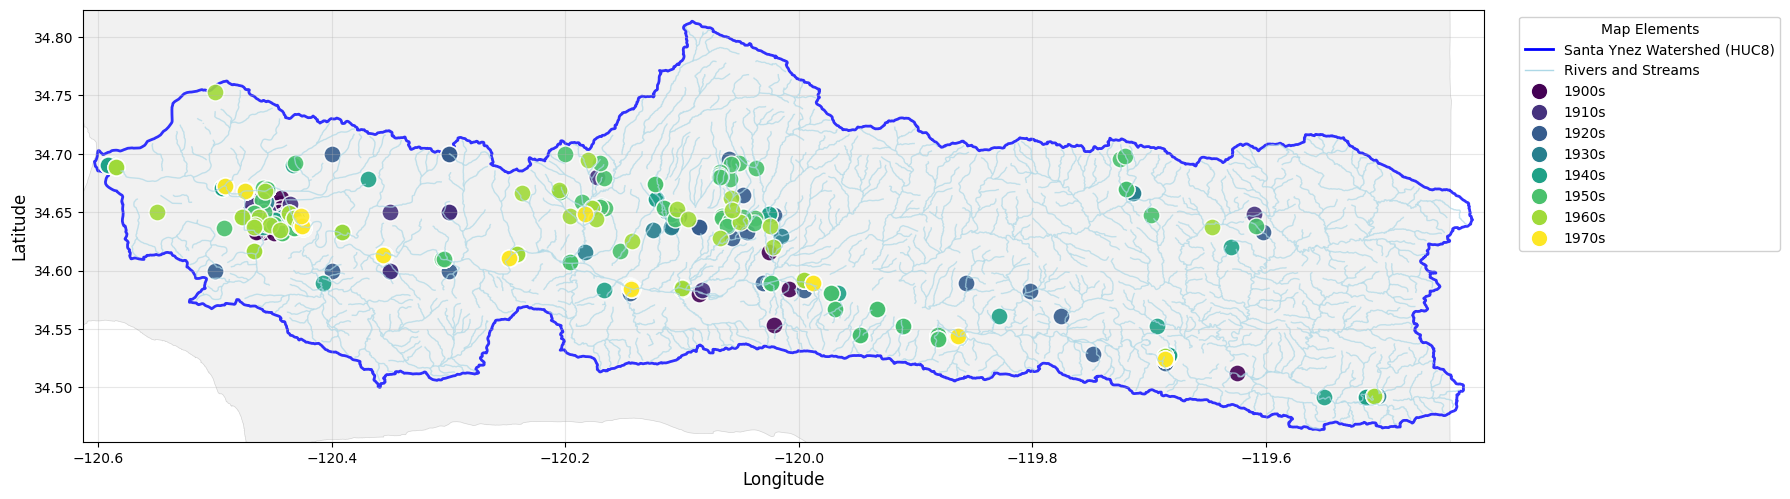


=== ANALYZING GAUGE SITE PROXIMITY TO STREAM ORDERS ===
Analyzing proximity of 707 gauge sites to streams...
Using stream order column: 'StreamOrderEdit'

=== STREAM ORDER PROXIMITY RESULTS ===
Total sites analyzed: 707

Sites by closest stream order:
  Stream Order 1: 99 sites
  Stream Order 2: 128 sites
  Stream Order 3: 44 sites
  Stream Order 4: 20 sites
  Stream Order 5: 416 sites

Sites by decade and closest stream order:
closest_stream_order   1   2   3  4    5
decade                                  
1900                   5  14   0  1   35
1910                   3  15   0  0   10
1920                  14  14   2  4   59
1930                   1   7  18  2    8
1940                   8  21   4  5  113
1950                  20  31   3  4   89
1960                  13  10   5  3   63
1970                   3   0   1  0   23

Sites furthest from streams (top 5):
station_name decade  closest_stream_order  distance_to_stream_km
     Unknown   1920                     5             

In [16]:
# ==== PART 2: SPATIAL FILTERING AND MAP CREATION ====
# This cell assumes the variables from Part 1 are available:
# santa_ynez_gdf, rivers, huc8_watershed

# Define the stream order column name
stream_order_col = 'StreamOrderEdit'

# Verify the column exists in the rivers dataset
if rivers is not None:
    if stream_order_col in rivers.columns:
        print(f"✓ Using stream order column: '{stream_order_col}'")
    else:
        print(f"⚠ Column '{stream_order_col}' not found in rivers dataset")
        print("Available columns:", rivers.columns.tolist())
        stream_order_col = None

if len(santa_ynez_gdf) > 0:
    
    # ==== FILTER SITES TO HUC BOUNDARY ====
    print(f"\n=== FILTERING SITES TO HUC BOUNDARY ===")
    
    # Perform spatial intersection to keep only sites within the HUC8 watershed
    if huc8_watershed is not None and len(santa_ynez_gdf) > 0:
        print(f"Sites before HUC filtering: {len(santa_ynez_gdf)}")
        
        # Ensure both datasets are in the same CRS
        if santa_ynez_gdf.crs != huc8_watershed.crs:
            print("Aligning coordinate systems...")
            if huc8_watershed.crs != "EPSG:4326":
                huc8_watershed = huc8_watershed.to_crs("EPSG:4326")
        
        # Perform spatial intersection - keep only points within the watershed
        santa_ynez_gdf_filtered = gpd.sjoin(santa_ynez_gdf, huc8_watershed, how='inner', predicate='within')
        
        # Remove duplicate columns created by the spatial join
        santa_ynez_gdf_filtered = santa_ynez_gdf_filtered.drop(columns=[col for col in santa_ynez_gdf_filtered.columns if col.endswith('_right')])
        
        print(f"Sites after HUC filtering: {len(santa_ynez_gdf_filtered)}")
        print(f"Removed {len(santa_ynez_gdf) - len(santa_ynez_gdf_filtered)} sites outside watershed boundary")
        
        # Update the geodataframe
        santa_ynez_gdf = santa_ynez_gdf_filtered
        
    else:
        if huc8_watershed is None:
            print("⚠ No HUC8 watershed available - cannot filter sites")
        if len(santa_ynez_gdf) == 0:
            print("⚠ No Santa Ynez sites to filter")
    
    # ==== CREATE ENHANCED MAP ====
    print(f"\n=== CREATING ENHANCED MAP ===")
    
    # Create single map: Santa Ynez sites colored by decade with watershed and rivers
    fig, ax = plt.subplots(1, 1, figsize=(18, 10))  # Wider figure to accommodate side legend
    
    # Plot Santa Barbara County boundary (light background)
    if 'sb_county' in globals():
        sb_county.plot(ax=ax, color='lightgray', alpha=0.3, edgecolor='gray', linewidth=0.5)
    
    # Plot HUC8 watershed if available
    if huc8_watershed is not None:
        huc8_watershed.plot(ax=ax, facecolor='none', edgecolor='blue', linewidth=2, alpha=0.8, label='Santa Ynez Watershed (HUC8)')
    
    # Plot rivers if available
    if rivers is not None:
        rivers.plot(ax=ax, color='lightblue', linewidth=1, alpha=0.7, label='Rivers and Streams')
    
    # Plot Santa Ynez sites colored by decade
    if len(santa_ynez_gdf) > 0 and 'decade' in santa_ynez_gdf.columns:
        # Create color map for decades
        decades = sorted(santa_ynez_gdf['decade'].dropna().unique())
        colors = plt.cm.viridis(np.linspace(0, 1, len(decades)))
        decade_colors = dict(zip(decades, colors))
        
        # Plot each decade separately
        for decade in decades:
            decade_sites = santa_ynez_gdf[santa_ynez_gdf['decade'] == decade]
            decade_sites.plot(ax=ax, color=decade_colors[decade], markersize=150, 
                            alpha=0.9, label=f"{int(decade)}s", edgecolor='white', linewidth=1)
        
        # Create custom legend
        legend_elements = []
        
        # Add watershed and rivers to legend if they exist
        if huc8_watershed is not None:
            legend_elements.append(Line2D([0], [0], color='blue', linewidth=2, label='Santa Ynez Watershed (HUC8)'))
        if rivers is not None:
            legend_elements.append(Line2D([0], [0], color='lightblue', linewidth=1, label='Rivers and Streams'))
        
        # Add decade markers to legend
        for decade in decades:
            legend_elements.append(Line2D([0], [0], marker='o', color='w', markerfacecolor=decade_colors[decade], 
                                        markersize=12, label=f"{int(decade)}s", markeredgecolor='white'))
        
        # Place legend outside the plot area on the right
        ax.legend(handles=legend_elements, title='Map Elements', bbox_to_anchor=(1.02, 1), 
                 loc='upper left', framealpha=0.9)
    else:
        # Plot all in same color if no decade info
        santa_ynez_gdf.plot(ax=ax, color='red', markersize=150, alpha=0.9, edgecolor='white', linewidth=1)
        
        # Simple legend
        legend_elements = []
        if huc8_watershed is not None:
            legend_elements.append(Line2D([0], [0], color='blue', linewidth=2, label='Santa Ynez Watershed (HUC8)'))
        if rivers is not None:
            legend_elements.append(Line2D([0], [0], color='lightblue', linewidth=1, label='Rivers and Streams'))
        legend_elements.append(Line2D([0], [0], marker='o', color='w', markerfacecolor='red', 
                                    markersize=12, label='Santa Ynez River Sites', markeredgecolor='white'))
        # Place legend outside the plot area on the right
        ax.legend(handles=legend_elements, title='Map Elements', bbox_to_anchor=(1.02, 1), 
                 loc='upper left', framealpha=0.9)
    
    ax.set_xlabel('Longitude', fontsize=12)
    ax.set_ylabel('Latitude', fontsize=12)
    
    # Set extent based on watershed if available, otherwise use sites
    if huc8_watershed is not None:
        # Zoom to watershed extent with small buffer
        minx, miny, maxx, maxy = huc8_watershed.total_bounds
        buffer = 0.01
        ax.set_xlim(minx - buffer, maxx + buffer)
        ax.set_ylim(miny - buffer, maxy + buffer)
    elif len(santa_ynez_gdf) > 0:
        # Zoom to sites extent with larger buffer
        minx, miny, maxx, maxy = santa_ynez_gdf.total_bounds
        buffer = 0.02
        ax.set_xlim(minx - buffer, maxx + buffer)
        ax.set_ylim(miny - buffer, maxy + buffer)
    
    # Add grid and improve appearance
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    
    plt.tight_layout()
    plt.show()
    
    # ==== STREAM ORDER PROXIMITY ANALYSIS ====
    print(f"\n=== ANALYZING GAUGE SITE PROXIMITY TO STREAM ORDERS ===")
    
    if rivers is not None and stream_order_col is not None and len(santa_ynez_gdf) > 0:
        from shapely.geometry import Point
        
        print(f"Analyzing proximity of {len(santa_ynez_gdf)} gauge sites to streams...")
        print(f"Using stream order column: '{stream_order_col}'")
        
        # Create a list to store results
        proximity_results = []
        
        # For each gauge site, find the closest stream and its order
        for idx, site in santa_ynez_gdf.iterrows():
            site_point = site.geometry
            
            # Calculate distance to all stream segments
            min_distance = float('inf')
            closest_stream_order = None
            
            for stream_idx, stream in rivers.iterrows():
                stream_geom = stream.geometry
                if stream_geom is not None:
                    # Get the closest point on the stream to our site
                    try:
                        closest_point_on_stream = stream_geom.interpolate(stream_geom.project(site_point))
                        distance = site_point.distance(closest_point_on_stream)
                        
                        if distance < min_distance:
                            min_distance = distance
                            closest_stream_order = stream[stream_order_col]
                    except Exception as e:
                        # Skip problematic geometries
                        continue
            
            # Store the result
            result = {
                'site_index': idx,
                'site_id': site.get('site_id', 'Unknown'),
                'station_name': site.get('station_name', 'Unknown'),
                'decade': site.get('decade', 'Unknown'),
                'year_start': site.get('year_start', 'Unknown'),
                'year_end': site.get('year_end', 'Unknown'),
                'longitude': site_point.x,
                'latitude': site_point.y,
                'closest_stream_order': closest_stream_order,
                'distance_to_stream_km': min_distance * 111.32 if min_distance != float('inf') else None  # Convert degrees to km (approximate)
            }
            proximity_results.append(result)
        
        # Convert to DataFrame for analysis
        proximity_df = pd.DataFrame(proximity_results)
        
        # Display results
        print(f"\n=== STREAM ORDER PROXIMITY RESULTS ===")
        print(f"Total sites analyzed: {len(proximity_df)}")
        
        # Summary by stream order
        print(f"\nSites by closest stream order:")
        stream_order_summary = proximity_df['closest_stream_order'].value_counts().sort_index()
        for order, count in stream_order_summary.items():
            if pd.notna(order):
                print(f"  Stream Order {int(order)}: {count} sites")
        
        # Summary by decade and stream order
        if 'decade' in proximity_df.columns:
            print(f"\nSites by decade and closest stream order:")
            try:
                decade_stream_summary = proximity_df.groupby(['decade', 'closest_stream_order']).size().unstack(fill_value=0)
                print(decade_stream_summary)
            except Exception as e:
                print(f"Could not create decade summary: {e}")
        
        # Show sites with furthest distance from streams
        valid_distances = proximity_df[proximity_df['distance_to_stream_km'].notna()]
        if len(valid_distances) > 0:
            print(f"\nSites furthest from streams (top 5):")
            furthest_sites = valid_distances.nlargest(5, 'distance_to_stream_km')[
                ['station_name', 'decade', 'closest_stream_order', 'distance_to_stream_km']
            ]
            print(furthest_sites.to_string(index=False))
        
        # Show detailed results table
        print(f"\n=== DETAILED PROXIMITY RESULTS ===")
        display_columns = ['station_name', 'decade', 'year_start', 'year_end', 'closest_stream_order', 'distance_to_stream_km']
        available_columns = [col for col in display_columns if col in proximity_df.columns]
        
        # Sort by stream order, then by decade
        proximity_display = proximity_df[available_columns].sort_values(['closest_stream_order', 'decade'])
        print(proximity_display.to_string(index=False))
        
        # Store results in a variable for further analysis
        globals()['stream_proximity_results'] = proximity_df
        print(f"\n✓ Results saved to 'stream_proximity_results' DataFrame")
        
    else:
        if rivers is None:
            print("⚠ No rivers data available for proximity analysis")
        elif stream_order_col is None:
            print("⚠ No stream order column found - cannot perform proximity analysis")
            if rivers is not None:
                print("Available columns in rivers dataset:", list(rivers.columns))
        elif len(santa_ynez_gdf) == 0:
            print("⚠ No gauge sites available for analysis")
    
    # ==== SUMMARY STATISTICS ====
    print(f"\n=== SUMMARY STATISTICS ===")
    print(f"Total Santa Ynez River sites (within watershed): {len(santa_ynez_gdf)}")
    
    if len(santa_ynez_gdf) > 0:
        if 'decade' in santa_ynez_gdf.columns:
            print(f"\nSites by decade:")
            decade_summary = santa_ynez_gdf['decade'].value_counts().sort_index()
            for decade, count in decade_summary.items():
                print(f"  {int(decade)}s: {count} sites")
        
        if 'data_source' in santa_ynez_gdf.columns:
            print(f"\nSites by data source:")
            source_summary = santa_ynez_gdf['data_source'].value_counts()
            for source, count in source_summary.items():
                print(f"  {source}: {count} sites")
        
        # Show coordinate bounds
        if len(santa_ynez_gdf) > 0:
            bounds = santa_ynez_gdf.total_bounds
            print(f"\nSpatial extent:")
            print(f"  Longitude: {bounds[0]:.4f} to {bounds[2]:.4f}")
            print(f"  Latitude: {bounds[1]:.4f} to {bounds[3]:.4f}")

else:
    print("No Santa Ynez River sites available for mapping.")

Geodatabase exists: True - C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\lakes\chap2map.gdb


C:\Users\aeliz\miniforge3\envs\hydro\Lib\site-packages\pyogrio\raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiLineString' is converted to 'MultiLineString Z'
  return ogr_read(


✓ Rivers loaded: 1653 features
✓ Lakes loaded:  132 features
Reprojecting rivers from EPSG:2229 -> EPSG:4326
Reprojecting lakes from EPSG:2229 -> EPSG:4326
Hydro data ready for mapping.
✓ Clipped to watershed: 34 lakes/wetlands within boundary
Stream orders found: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5)]
Plotted 818 streams of order 1
Plotted 364 streams of order 2
Plotted 172 streams of order 3
Plotted 142 streams of order 4
Plotted 157 streams of order 5
✓ Plotted 34 lakes/wetlands on map


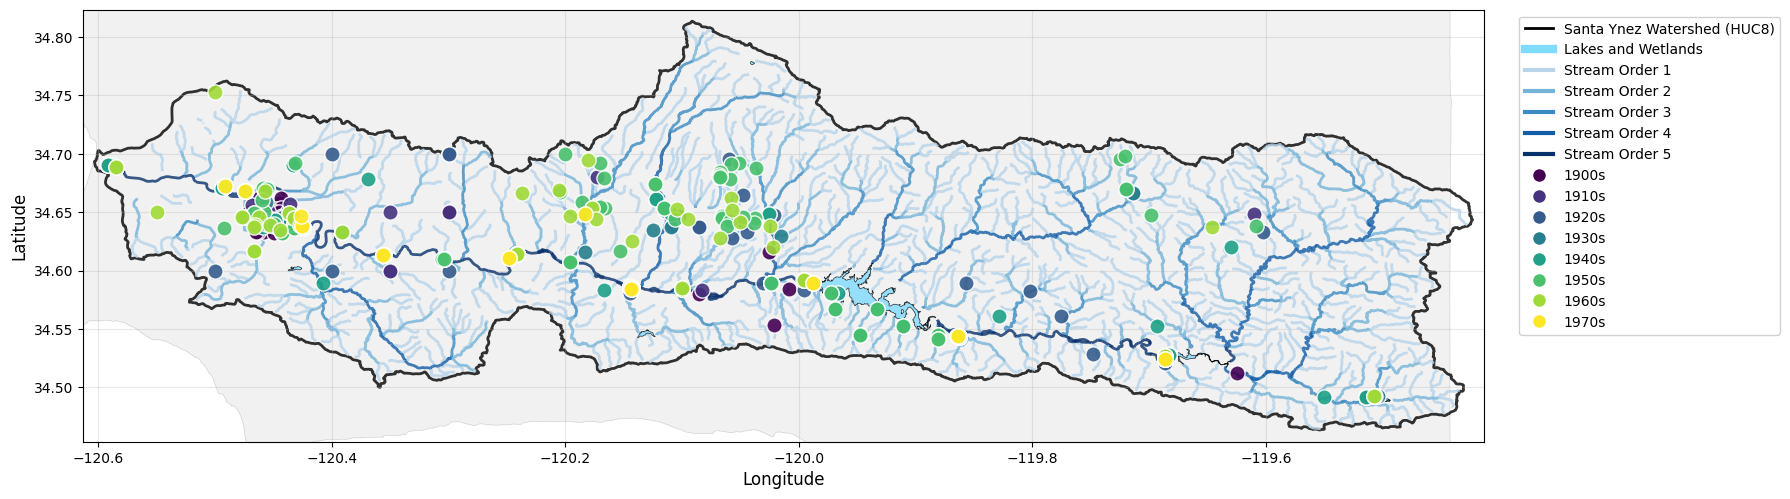


✓ Map created with 5 different stream orders
✓ Plotted 707 gauge sites
✓ Plotted 34 lakes and wetlands


In [28]:
# ==== STREAM ORDER COLORED MAP ====
# This creates a map with rivers colored by stream order and gauge sites colored by decade

import os
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np
import geopandas as gpd
from matplotlib.lines import Line2D

# ---------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------
gdb_path = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\lakes\chap2map.gdb"

# Initialize
rivers = None
lakes  = None

# ---------------------------------------------------------------------
# Load rivers and lakes explicitly from the GDB
# ---------------------------------------------------------------------
gdb_exists = os.path.exists(gdb_path)
print(f"Geodatabase exists: {gdb_exists} - {gdb_path}")

try:
    if not gdb_exists:
        raise FileNotFoundError(f"GDB not found: {gdb_path}")

    # Exact layer names you provided
    rivers = gpd.read_file(gdb_path, layer="StreamsandRivers_Clip")
    lakes  = gpd.read_file(gdb_path, layer="LakesNationalWetlandsInventory_ExportFeatures")

    print(f"✓ Rivers loaded: {len(rivers)} features")
    print(f"✓ Lakes loaded:  {len(lakes)} features")

    # Normalize CRS to EPSG:4326 for consistency (only if defined)
    if rivers.crs is not None and str(rivers.crs) != "EPSG:4326":
        print(f"Reprojecting rivers from {rivers.crs} -> EPSG:4326")
        rivers = rivers.to_crs("EPSG:4326")
    if lakes.crs is not None and str(lakes.crs) != "EPSG:4326":
        print(f"Reprojecting lakes from {lakes.crs} -> EPSG:4326")
        lakes = lakes.to_crs("EPSG:4326")

    print("Hydro data ready for mapping.")

    # Optional: clip lakes to watershed if available
    if ('huc8_watershed' in globals()) and (huc8_watershed is not None) and (lakes is not None):
        if lakes.crs != huc8_watershed.crs:
            print("Converting lakes CRS to match watershed before clipping…")
            lakes = lakes.to_crs(huc8_watershed.crs)
        lakes_clipped = gpd.clip(lakes, huc8_watershed)
        print(f"✓ Clipped to watershed: {len(lakes_clipped)} lakes/wetlands within boundary")
        lakes = lakes_clipped if len(lakes_clipped) > 0 else None

except Exception as e:
    print(f"⚠ Error reading GDB layers: {e}")
    print("If needed, install dependencies: pip install fiona geopandas")
    rivers, lakes = None, None

# ---------------------------------------------------------------------
# Create enhanced map with stream order coloring
# ---------------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(18, 10))

# Plot Santa Barbara County boundary (light background)
if 'sb_county' in globals() and sb_county is not None:
    sb_county.plot(ax=ax, color='lightgray', alpha=0.3, edgecolor='gray', linewidth=0.5)

# Plot HUC8 watershed boundary
if 'huc8_watershed' in globals() and (huc8_watershed is not None):
    huc8_watershed.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=2, alpha=0.8)

# Plot rivers colored by stream order
stream_orders = []
order_colors = {}
if (rivers is not None) and ('StreamOrderEdit' in rivers.columns):
    stream_orders = sorted(rivers['StreamOrderEdit'].dropna().unique())
    print(f"Stream orders found: {stream_orders}")

    # Color ramp: darkest blue for highest order
    n_orders = len(stream_orders)
    blues_colors = plt.cm.Blues(np.linspace(0.3, 1.0, n_orders))
    order_colors = {order: blues_colors[i] for i, order in enumerate(stream_orders)}

    for order in stream_orders:
        order_streams = rivers[rivers['StreamOrderEdit'] == order]
        if len(order_streams) > 0:
            order_streams.plot(ax=ax, color=order_colors[order], linewidth=2,
                               alpha=0.8, zorder=2)
            try:
                print(f"Plotted {len(order_streams)} streams of order {int(order)}")
            except Exception:
                print(f"Plotted {len(order_streams)} streams of order {order}")

# Plot lakes (after rivers so they’re visible)
if lakes is not None and len(lakes) > 0:
    lakes.plot(ax=ax,
               facecolor='#7FDBFF',   # readable cyan fill
               edgecolor='black',     # outline so they pop over rivers
               linewidth=0.5,
               alpha=0.8,
               zorder=6)
    print(f"✓ Plotted {len(lakes)} lakes/wetlands on map")

# Plot Santa Ynez gauge sites colored by decade
if 'santa_ynez_gdf' in globals() and (len(santa_ynez_gdf) > 0):
    if 'decade' in santa_ynez_gdf.columns:
        decades = sorted(santa_ynez_gdf['decade'].dropna().unique())
        decade_colors_map = plt.cm.viridis(np.linspace(0, 1, len(decades)))
        decade_colors = dict(zip(decades, decade_colors_map))

        for decade in decades:
            decade_sites = santa_ynez_gdf[santa_ynez_gdf['decade'] == decade]
            decade_sites.plot(ax=ax, color=decade_colors[decade], markersize=120,
                              alpha=0.9, edgecolor='white', linewidth=1, zorder=7)
    else:
        santa_ynez_gdf.plot(ax=ax, color='red', markersize=120, alpha=0.9,
                            edgecolor='white', linewidth=1, zorder=7)

# ---------------------------------------------------------------------
# Legend
# ---------------------------------------------------------------------
legend_elements = []

# Watershed
if 'huc8_watershed' in globals() and (huc8_watershed is not None):
    legend_elements.append(Line2D([0], [0], color='black', linewidth=2,
                                  label='Santa Ynez Watershed (HUC8)'))

# Lakes
if lakes is not None and len(lakes) > 0:
    legend_elements.append(Line2D([0], [0], color='#7FDBFF', linewidth=6,
                                  label='Lakes and Wetlands'))

# Stream orders
if (rivers is not None) and ('StreamOrderEdit' in rivers.columns) and stream_orders:
    for order in stream_orders:
        legend_elements.append(Line2D([0], [0], color=order_colors[order], linewidth=3,
                                      label=f'Stream Order {int(order)}' if isinstance(order, (int, np.integer, float)) else f'Stream Order {order}'))

# Gauge site decades
if 'santa_ynez_gdf' in globals() and (len(santa_ynez_gdf) > 0):
    if 'decade' in santa_ynez_gdf.columns:
        for decade in decades:
            legend_elements.append(Line2D([0], [0], marker='o', color='w',
                                          markerfacecolor=decade_colors[decade],
                                          markersize=10, label=f"{int(decade)}s",
                                          markeredgecolor='white'))
    else:
        legend_elements.append(Line2D([0], [0], marker='o', color='w',
                                      markerfacecolor='red', markersize=10,
                                      label='Gauge Sites', markeredgecolor='white'))

ax.legend(handles=legend_elements, bbox_to_anchor=(1.02, 1),
          loc='upper left', framealpha=0.9, fontsize=10)

# ---------------------------------------------------------------------
# Axes, extent, layout
# ---------------------------------------------------------------------
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)

# Extent from watershed, else sites
if 'huc8_watershed' in globals() and (huc8_watershed is not None):
    minx, miny, maxx, maxy = huc8_watershed.total_bounds
    buffer = 0.01
    ax.set_xlim(minx - buffer, maxx + buffer)
    ax.set_ylim(miny - buffer, maxy + buffer)
elif 'santa_ynez_gdf' in globals() and (len(santa_ynez_gdf) > 0):
    minx, miny, maxx, maxy = santa_ynez_gdf.total_bounds
    buffer = 0.02
    ax.set_xlim(minx - buffer, maxx + buffer)
    ax.set_ylim(miny - buffer, maxy + buffer)

ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig(r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\plots\streamorder_map.png",
            dpi=300, bbox_inches="tight")

plt.show()

print(f"\n✓ Map created with {len(stream_orders) if stream_orders else 0} different stream orders")
if 'santa_ynez_gdf' in globals():
    print(f"✓ Plotted {len(santa_ynez_gdf)} gauge sites")
if lakes is not None and len(lakes) > 0:
    print(f"✓ Plotted {len(lakes)} lakes and wetlands")


Geodatabase exists: True - C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\lakes\chap2map.gdb
✓ Rivers loaded: 1653 features
✓ Lakes loaded:  132 features
Reprojecting rivers from EPSG:2229 -> EPSG:4326


C:\Users\aeliz\miniforge3\envs\hydro\Lib\site-packages\pyogrio\raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiLineString' is converted to 'MultiLineString Z'
  return ogr_read(


Reprojecting lakes from EPSG:2229 -> EPSG:4326
✓ Clipped to watershed: 34 lakes/wetlands within boundary
Stream orders found: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5)]


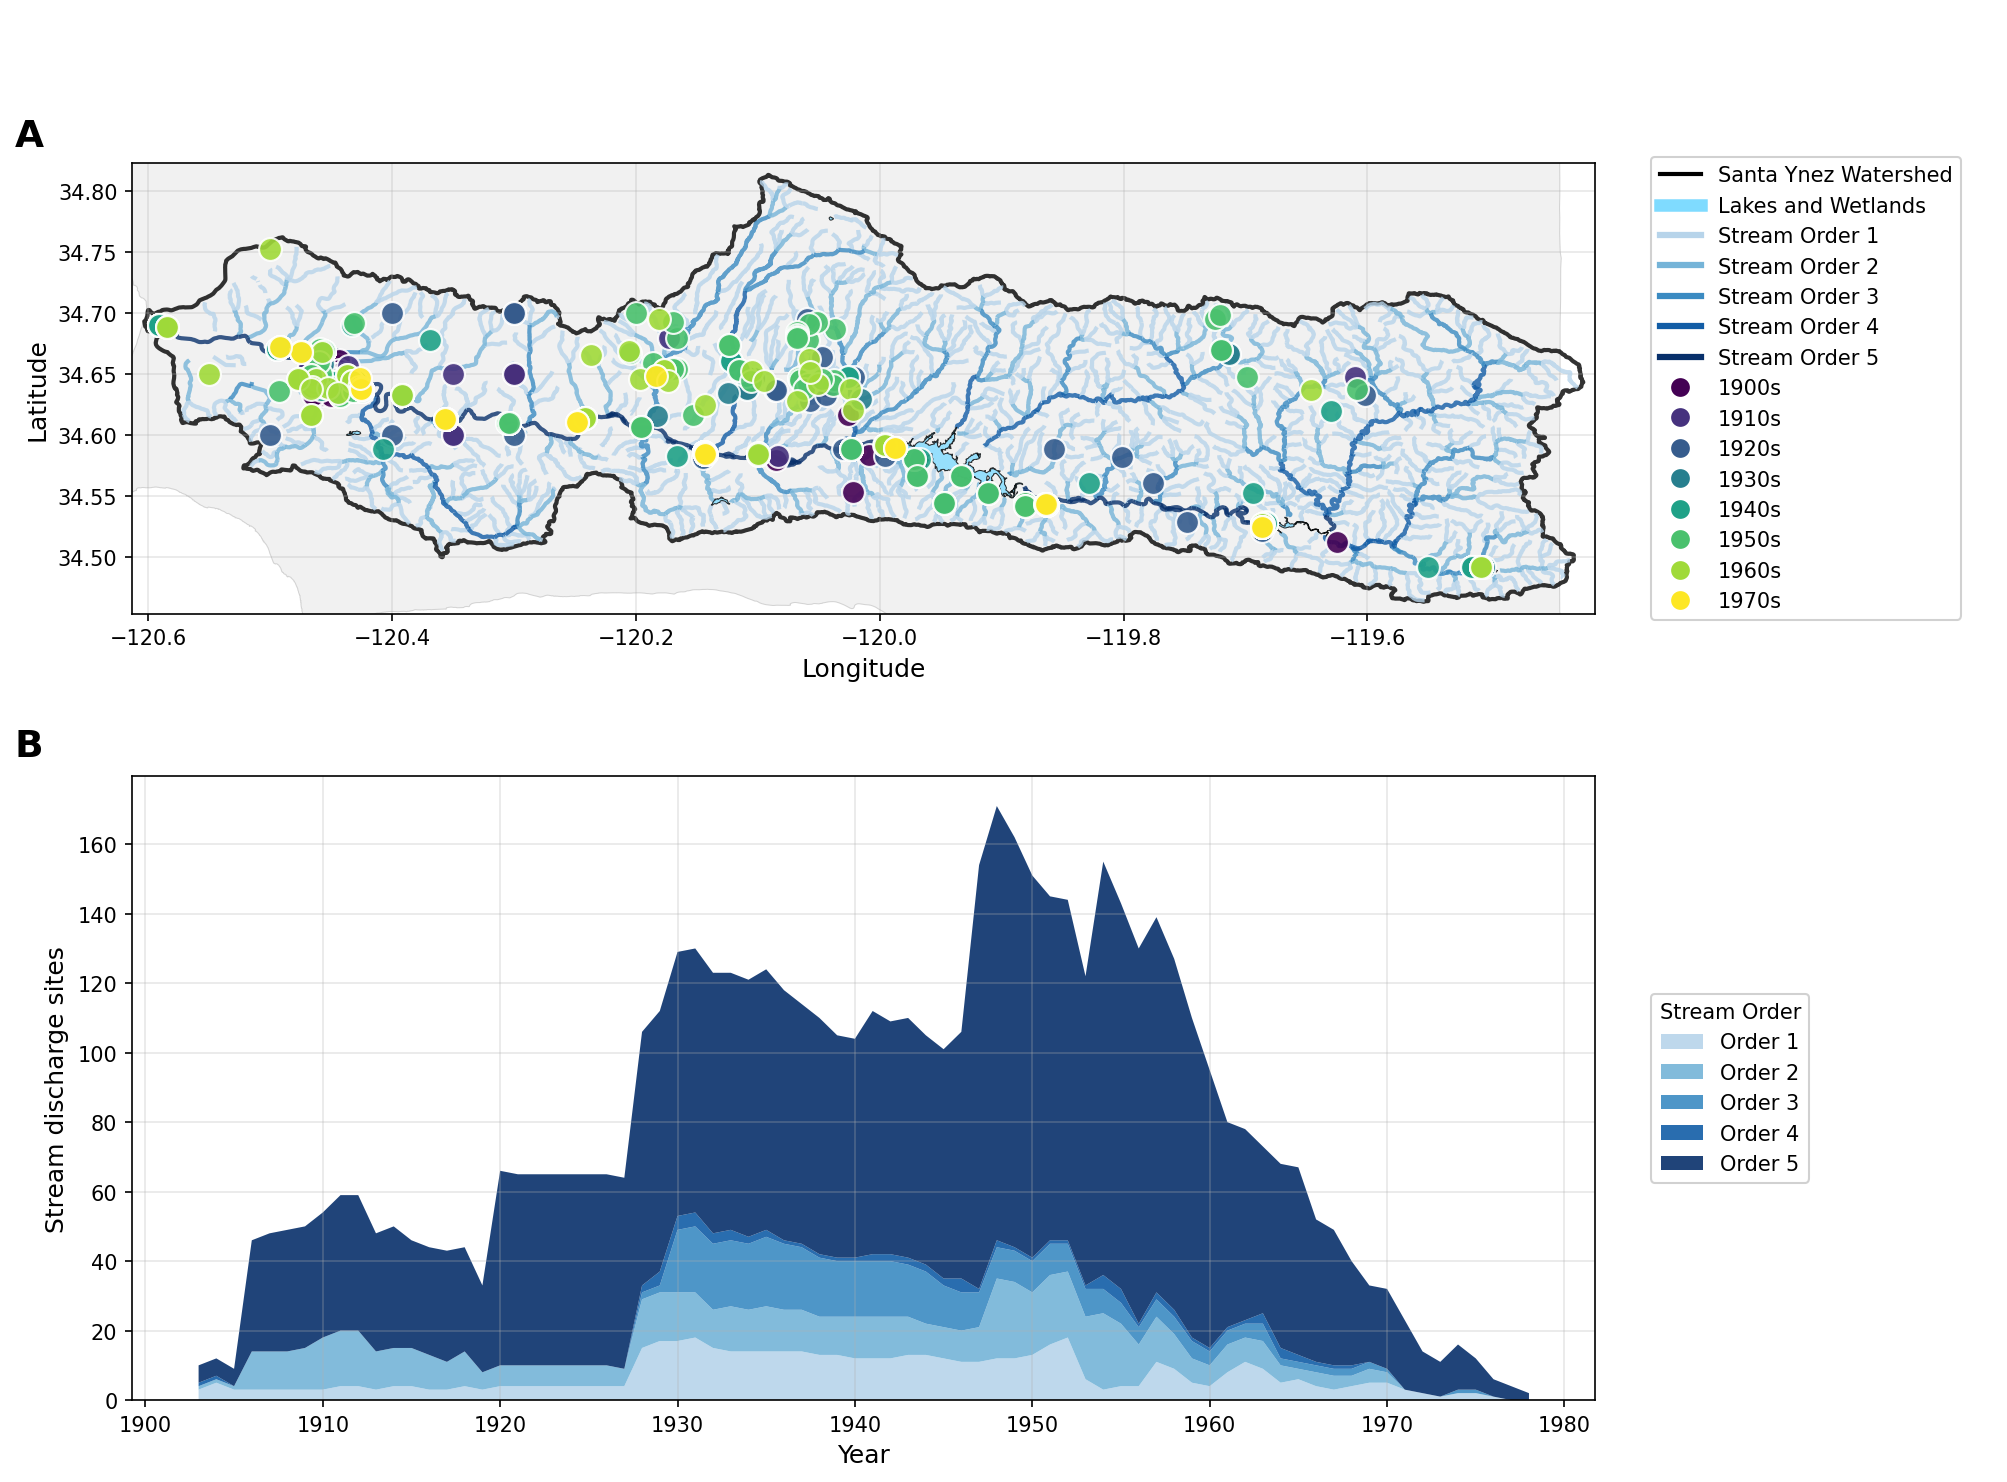


✓ Combined figure created!
✓ Map with 5 different stream orders
✓ Map plotted 707 gauge sites
✓ Map plotted 34 lakes and wetlands
✓ Timeline shows data from 1903 to 1978


In [44]:
# === COMBINED FIGURE: Stream Order Map (Panel A) + Timeline (Panel B) ===
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import geopandas as gpd
from matplotlib.lines import Line2D
from collections import defaultdict

# ------------------------------------------------------------
# 1) Load the results DataFrame for timeline
# ------------------------------------------------------------
if 'stream_proximity_results' not in globals():
    results_path = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\stream_proximity_results.csv"
    stream_proximity_results = pd.read_csv(results_path)

df = stream_proximity_results.copy()
df['year_start'] = pd.to_numeric(df['year_start'], errors='coerce')
df['year_end']   = pd.to_numeric(df['year_end'], errors='coerce')
df['closest_stream_order'] = pd.to_numeric(df['closest_stream_order'], errors='coerce')
df = df.dropna(subset=['year_start', 'year_end', 'closest_stream_order'])
df['year_start'] = df['year_start'].astype(int)
df['year_end']   = df['year_end'].astype(int)
df['closest_stream_order'] = df['closest_stream_order'].astype(int)

# ------------------------------------------------------------
# 2) Load geographic data for map
# ------------------------------------------------------------
gdb_path = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\lakes\chap2map.gdb"
rivers = None
lakes  = None

gdb_exists = os.path.exists(gdb_path)
print(f"Geodatabase exists: {gdb_exists} - {gdb_path}")

try:
    if not gdb_exists:
        raise FileNotFoundError(f"GDB not found: {gdb_path}")

    rivers = gpd.read_file(gdb_path, layer="StreamsandRivers_Clip")
    lakes  = gpd.read_file(gdb_path, layer="LakesNationalWetlandsInventory_ExportFeatures")

    print(f"✓ Rivers loaded: {len(rivers)} features")
    print(f"✓ Lakes loaded:  {len(lakes)} features")

    if rivers.crs is not None and str(rivers.crs) != "EPSG:4326":
        print(f"Reprojecting rivers from {rivers.crs} -> EPSG:4326")
        rivers = rivers.to_crs("EPSG:4326")
    if lakes.crs is not None and str(lakes.crs) != "EPSG:4326":
        print(f"Reprojecting lakes from {lakes.crs} -> EPSG:4326")
        lakes = lakes.to_crs("EPSG:4326")

    if ('huc8_watershed' in globals()) and (huc8_watershed is not None) and (lakes is not None):
        if lakes.crs != huc8_watershed.crs:
            print("Converting lakes CRS to match watershed before clipping…")
            lakes = lakes.to_crs(huc8_watershed.crs)
        lakes_clipped = gpd.clip(lakes, huc8_watershed)
        print(f"✓ Clipped to watershed: {len(lakes_clipped)} lakes/wetlands within boundary")
        lakes = lakes_clipped if len(lakes_clipped) > 0 else None

except Exception as e:
    print(f"⚠ Error reading GDB layers: {e}")
    rivers, lakes = None, None

# ------------------------------------------------------------
# 3) Build timeline data
# ------------------------------------------------------------
counts = defaultdict(int)
for _, row in df.iterrows():
    ys, ye, order = row['year_start'], row['year_end'], row['closest_stream_order']
    if ys > ye:
        ys, ye = ye, ys
    for y in range(ys, ye + 1):
        counts[(y, order)] += 1

if counts:
    idx = pd.MultiIndex.from_tuples(counts.keys(), names=['year', 'closest_stream_order'])
    timeline = pd.Series(counts, index=idx).sort_index().rename('count').reset_index()
    pvt_t = timeline.pivot(index='year', columns='closest_stream_order', values='count').fillna(0).astype(int)
else:
    pvt_t = pd.DataFrame()

# ------------------------------------------------------------
# 4) Set up consistent color schemes
# ------------------------------------------------------------
stream_orders = []
stream_order_colors = {}

if (rivers is not None) and ('StreamOrderEdit' in rivers.columns):
    stream_orders = sorted(rivers['StreamOrderEdit'].dropna().unique())
    print(f"Stream orders found: {stream_orders}")

if not pvt_t.empty:
    timeline_orders = sorted(pvt_t.columns.tolist())
    if timeline_orders:
        stream_orders = timeline_orders

if stream_orders:
    n_orders = len(stream_orders)
    blues_colors = plt.cm.Blues(np.linspace(0.3, 1.0, n_orders))
    stream_order_colors = {order: blues_colors[i] for i, order in enumerate(stream_orders)}

decade_colors_map = {}
if 'santa_ynez_gdf' in globals() and (len(santa_ynez_gdf) > 0):
    if 'decade' in santa_ynez_gdf.columns:
        decades = sorted(santa_ynez_gdf['decade'].dropna().unique())
        viridis_colors = plt.cm.viridis(np.linspace(0, 1, len(decades)))
        decade_colors_map = dict(zip(decades, viridis_colors))

# ------------------------------------------------------------
# 5) Create combined figure (tight vertical spacing, no panel titles)
# ------------------------------------------------------------
fig = plt.figure(figsize=(16, 12), dpi=150)

# Minimal vertical space between panels
gs = fig.add_gridspec(
    2, 2,
    width_ratios=[5, 1.2],
    height_ratios=[1.2, 1],
    hspace=0.02,          # << tightened
    wspace=0.05
)

# =========================
# PANEL A - MAP (top left)
# =========================
ax_map = fig.add_subplot(gs[0, 0])

if 'sb_county' in globals() and sb_county is not None:
    sb_county.plot(ax=ax_map, color='lightgray', alpha=0.3, edgecolor='gray', linewidth=0.5)

if 'huc8_watershed' in globals() and (huc8_watershed is not None):
    huc8_watershed.plot(ax=ax_map, facecolor='none', edgecolor='black', linewidth=2, alpha=0.8)

if (rivers is not None) and ('StreamOrderEdit' in rivers.columns) and stream_orders:
    for order in stream_orders:
        if order in stream_order_colors:
            order_streams = rivers[rivers['StreamOrderEdit'] == order]
            if len(order_streams) > 0:
                order_streams.plot(ax=ax_map, color=stream_order_colors[order], linewidth=2, alpha=0.8, zorder=2)

if lakes is not None and len(lakes) > 0:
    lakes.plot(ax=ax_map, facecolor='#7FDBFF', edgecolor='black', linewidth=0.5, alpha=0.8, zorder=6)

if 'santa_ynez_gdf' in globals() and (len(santa_ynez_gdf) > 0):
    if 'decade' in santa_ynez_gdf.columns and decade_colors_map:
        for decade in decade_colors_map.keys():
            decade_sites = santa_ynez_gdf[santa_ynez_gdf['decade'] == decade]
            if len(decade_sites) > 0:
                decade_sites.plot(ax=ax_map, color=decade_colors_map[decade], markersize=120,
                                  alpha=0.9, edgecolor='white', linewidth=1, zorder=7)
    else:
        santa_ynez_gdf.plot(ax=ax_map, color='red', markersize=120, alpha=0.9,
                            edgecolor='white', linewidth=1, zorder=7)

# Axes labels, no title
ax_map.set_xlabel('Longitude', fontsize=12)
ax_map.set_ylabel('Latitude', fontsize=12)

# Extent
if 'huc8_watershed' in globals() and (huc8_watershed is not None):
    minx, miny, maxx, maxy = huc8_watershed.total_bounds
    buffer = 0.01
    ax_map.set_xlim(minx - buffer, maxx + buffer)
    ax_map.set_ylim(miny - buffer, maxy + buffer)
elif 'santa_ynez_gdf' in globals() and (len(santa_ynez_gdf) > 0):
    minx, miny, maxx, maxy = santa_ynez_gdf.total_bounds
    buffer = 0.02
    ax_map.set_xlim(minx - buffer, maxx + buffer)
    ax_map.set_ylim(miny - buffer, maxy + buffer)

ax_map.grid(True, alpha=0.3)
ax_map.set_aspect('equal')

# Panel label "A" at far-left top
ax_map.text(-0.08, 1.02, "A", transform=ax_map.transAxes,
            fontsize=18, fontweight='bold', ha='left', va='bottom', clip_on=False)

# =========================
# MAP LEGEND (top right)
# =========================
ax_map_legend = fig.add_subplot(gs[0, 1])
ax_map_legend.axis('off')

legend_elements_map = []
if 'huc8_watershed' in globals() and (huc8_watershed is not None):
    legend_elements_map.append(Line2D([0], [0], color='black', linewidth=2, label='Santa Ynez Watershed'))
if lakes is not None and len(lakes) > 0:
    legend_elements_map.append(Line2D([0], [0], color='#7FDBFF', linewidth=6, label='Lakes and Wetlands'))
if stream_orders and stream_order_colors:
    for order in stream_orders:
        legend_elements_map.append(Line2D([0], [0], color=stream_order_colors[order], linewidth=3,
                                          label=f'Stream Order {int(order)}'))
if 'santa_ynez_gdf' in globals() and (len(santa_ynez_gdf) > 0):
    if decade_colors_map:
        for decade in sorted(decade_colors_map.keys()):
            legend_elements_map.append(Line2D([0], [0], marker='o', color='w',
                                              markerfacecolor=decade_colors_map[decade],
                                              markersize=10, label=f"{int(decade)}s",
                                              markeredgecolor='white'))
    else:
        legend_elements_map.append(Line2D([0], [0], marker='o', color='w',
                                          markerfacecolor='red', markersize=10,
                                          label='Gauge Sites', markeredgecolor='white'))

if legend_elements_map:
    ax_map_legend.legend(handles=legend_elements_map, loc='center left',
                         bbox_to_anchor=(0, 0.5), framealpha=0.9, fontsize=10)

# =========================
# PANEL B - TIMELINE (bottom left)
# =========================
ax_timeline = fig.add_subplot(gs[1, 0])

if not pvt_t.empty and stream_order_colors:
    years = pvt_t.index.values
    orders_sorted = sorted(pvt_t.columns.tolist())
    y_stacks = [pvt_t[o].values for o in orders_sorted]
    ax_timeline.stackplot(years, y_stacks,
                          labels=[f'Order {int(o)}' for o in orders_sorted],
                          colors=[stream_order_colors[o] for o in orders_sorted],
                          alpha=0.9)

ax_timeline.set_xlabel("Year", fontsize=12)
ax_timeline.set_ylabel("Stream discharge sites", fontsize=12)
ax_timeline.grid(True, alpha=0.3)

# Panel label "B" at far-left top
ax_timeline.text(-0.08, 1.02, "B", transform=ax_timeline.transAxes,
                 fontsize=18, fontweight='bold', ha='left', va='bottom', clip_on=False)

# =========================
# TIMELINE LEGEND (bottom right)
# =========================
ax_timeline_legend = fig.add_subplot(gs[1, 1])
ax_timeline_legend.axis('off')

if not pvt_t.empty and stream_order_colors:
    legend_elements_timeline = []
    orders_sorted = sorted(pvt_t.columns.tolist())
    for order in orders_sorted:
        legend_elements_timeline.append(
            plt.Rectangle((0, 0), 1, 1, facecolor=stream_order_colors[order], alpha=0.9, label=f'Order {int(order)}')
        )
    ax_timeline_legend.legend(handles=legend_elements_timeline, title="Stream Order",
                              loc='center left', bbox_to_anchor=(0, 0.5),
                              framealpha=0.9, fontsize=10)

# ------------------------------------------------------------
# 6) Save the combined figure
# ------------------------------------------------------------
outdir = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\plots"
os.makedirs(outdir, exist_ok=True)

plt.savefig(os.path.join(outdir, "combined_map_timeline_figure.png"),
            dpi=300, bbox_inches="tight")
plt.show()

print(f"\n✓ Combined figure created!")
print(f"✓ Map with {len(stream_orders) if stream_orders else 0} different stream orders")
if 'santa_ynez_gdf' in globals():
    print(f"✓ Map plotted {len(santa_ynez_gdf)} gauge sites")
if lakes is not None and len(lakes) > 0:
    print(f"✓ Map plotted {len(lakes)} lakes and wetlands")
if not pvt_t.empty:
    print(f"✓ Timeline shows data from {pvt_t.index.min()} to {pvt_t.index.max()}")
